In [1]:
import sys
print(sys.executable)

c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Scripts\python.exe


# DLinear model and M5 dataset

### Libraries

In [1]:
import importlib.util
import subprocess
import sys

required = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "torch": "torch>=2.1",
    "tqdm": "tqdm>=4.65",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    print("missing packages: " + ", ".join(missing))

print("Environment ready")

Environment ready


In [2]:
from pathlib import Path
from types import SimpleNamespace
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
from models import DLinear
print(DLinear)

FEATURE_PATH = PROJECT_ROOT / "data/m5/processed/m5_long_features.parquet"
SPLIT_PATH = PROJECT_ROOT / "data/m5/processed/splits/normal_series.csv"



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


<class 'models.DLinear.Model'>


c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

### Hyperparameters

In [ ]:
SEQ_LEN = 56
PRED_LEN = 28

N_SERIES = 0 #0 to use all series, otherwise specify the number of series to use
BATCH_SIZE = 64
SAMPLES_PER_EPOCH = 20_000 #10_000
EPOCHS = 10 #5
LEARNING_RATE = 1e-3
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

### Read data

In [42]:
# Reading the normal series CSV file to get the series indices
normal_series = pd.read_csv(SPLIT_PATH)

all_series = normal_series["series_idx"].dropna().astype(int).tolist()

if N_SERIES is None or N_SERIES <= 0:
    selected_series = all_series
else:
    selected_series = (
        normal_series["series_idx"]
        .sample(n=min(N_SERIES, len(all_series)), random_state=RANDOM_SEED)
        .astype(int)
        .tolist()
    )

if len(selected_series) == 0:
    selected_series = all_series

print(len(selected_series), "series selected for training.")


7600 series selected for training.


In [43]:
# Read long format file with features and filter for selected series
df = pd.read_parquet(
    FEATURE_PATH,
    columns=["series_idx", "time_idx", "date", "sales", "log_sales"], #Filter columns to reduce memory usage
    filters=[("series_idx", "in", selected_series)],
)

df = df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

df.head()

,series_idx,time_idx,date,sales,log_sales
0,1,0,2011-01-29,2,1.098612
1,1,1,2011-01-30,0,0.000000
2,1,2,2011-01-31,0,0.000000
3,1,3,2011-02-01,0,0.000000
4,1,4,2011-02-02,1,0.693147


#### Data exploration

In [44]:
print("Rows:", len(df))
print("Series:", df["series_idx"].nunique())
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Time range:", df["time_idx"].min(), "to", df["time_idx"].max())
print("Missing values:")
print(df.isna().sum())

Rows: 14538800
Series: 7600
Date range: 2011-01-29 00:00:00 to 2016-04-24 00:00:00
Time range: 0 to 1912
Missing values:
series_idx    0
time_idx      0
date          0
sales         0
log_sales     0
dtype: int64


In [45]:
# List of time series arrays used for window sampling.

series_arrays_log = []
series_arrays_sales = []
series_ids = []

for series_idx, group in df.groupby("series_idx", sort=True):
    group = group.sort_values("time_idx")

    log_sales = group["log_sales"].to_numpy(dtype=np.float32).copy()
    sales = group["sales"].to_numpy(dtype=np.float32).copy()

    series_arrays_log.append(log_sales)
    series_arrays_sales.append(sales)
    series_ids.append(series_idx)

print("Number of series arrays:", len(series_arrays_log))
print("First series length:", len(series_arrays_log[0]))

Number of series arrays: 7600
First series length: 1913


In [46]:
series_arrays_log[0]

array([1.0986123, 0.       , 0.       , ..., 0.       , 0.       ,
       1.609438 ], shape=(1913,), dtype=float32)

In [47]:
# Check series have enough history for the chosen window sizes.

minimum_required_length = SEQ_LEN + PRED_LEN + PRED_LEN

valid_positions = [
    i
    for i, values in enumerate(series_arrays_log)
    if len(values) >= minimum_required_length and not np.isnan(values).any()
]

series_arrays_log = [series_arrays_log[i] for i in valid_positions]
series_arrays_sales = [series_arrays_sales[i] for i in valid_positions]
series_ids = [series_ids[i] for i in valid_positions]

print("Valid series:", len(series_arrays_log))
print("Minimum required length:", minimum_required_length)
print("Shortest valid series:", min(len(values) for values in series_arrays_log))



Valid series: 7600
Minimum required length: 112
Shortest valid series: 1913


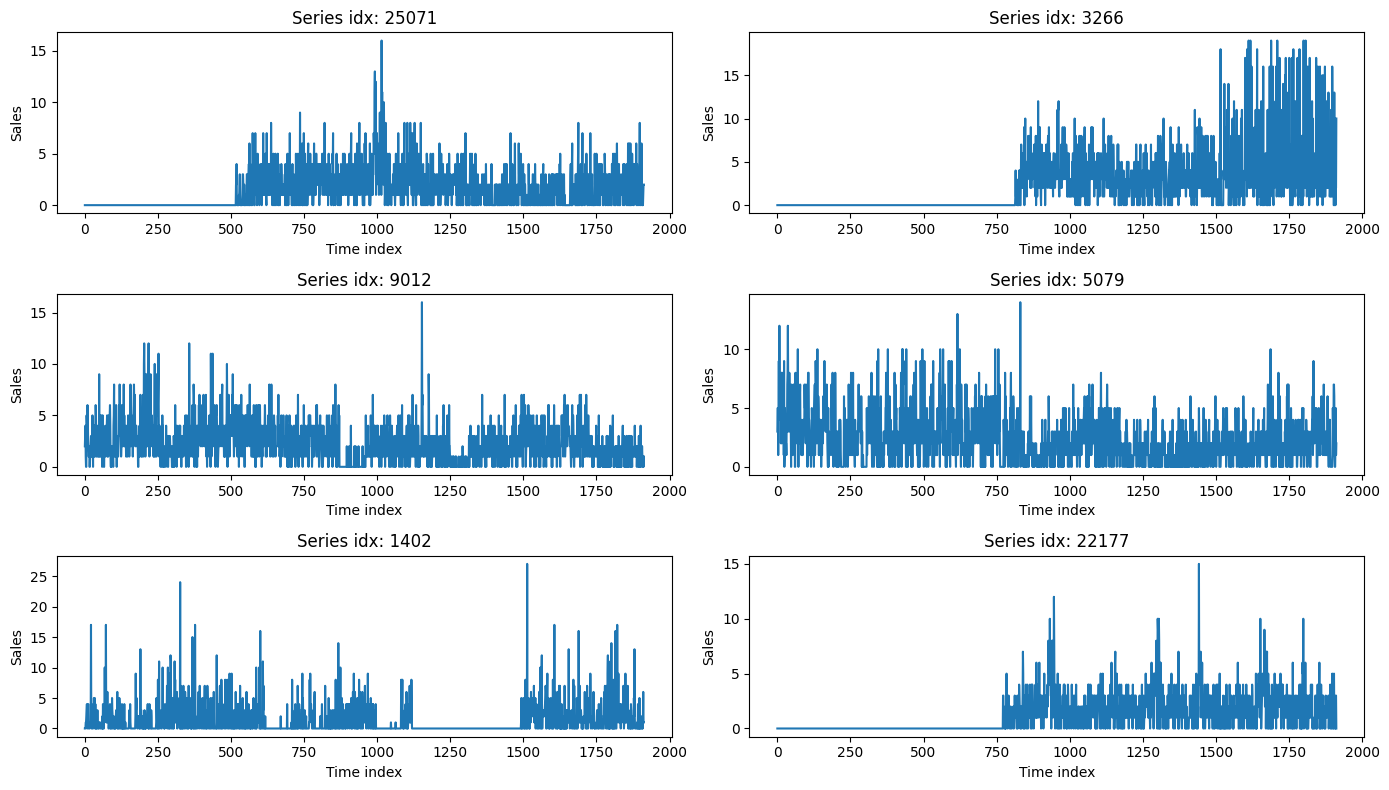

In [48]:
# Plot some series.

example_positions = np.random.choice(len(series_arrays_sales), size=6, replace=False)

plt.figure(figsize=(14, 8))

for plot_number, position in enumerate(example_positions, start=1):
    plt.subplot(3, 2, plot_number)
    plt.plot(series_arrays_sales[position])
    plt.title(f"Series idx: {series_ids[position]}")
    plt.xlabel("Time index")
    plt.ylabel("Sales")

plt.tight_layout()
plt.show()

### Data preprocessing

In [50]:
# Dataset for global random window training.
# One model is trained using windows sampled from many different series.

class RandomWindowDataset(Dataset):
    def __init__(self, series_arrays, seq_len, pred_len, samples_per_epoch, seed=42):
        self.series_arrays = series_arrays
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.samples_per_epoch = samples_per_epoch
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, index):
        series_position = self.rng.integers(0, len(self.series_arrays))
        series = self.series_arrays[series_position]

        # Exclude validation horixon
        validation_start = len(series) - self.pred_len
        max_start = validation_start - self.seq_len - self.pred_len

        start = self.rng.integers(0, max_start + 1)

        # randomly choose the window
        x = series[start : start + self.seq_len].copy()
        y = series[start + self.seq_len : start + self.seq_len + self.pred_len].copy()

        return torch.from_numpy(x[:, None]), torch.from_numpy(y[:, None])

In [51]:
# DataLoader that creates batches of random windows.
# All windows train the same global model.

train_dataset = RandomWindowDataset(
    series_arrays=series_arrays_log,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    samples_per_epoch=SAMPLES_PER_EPOCH,
    seed=RANDOM_SEED,
)
# One epoch will have #SAMPLES_PER_EPOCH examples 
# with X length = SEQ_LEN  and Y length = PRED_LEN


# Group into bathces
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
# X shape = [BATCH_SIZE, SEQ_LEN. 1]
# Y shape = [BATCH_SIZE, PRED_LEN. 1]

### Model

In [52]:
# One  global DLinear model.
# enc_in=1 because this first model only uses log_sales as the input channel.

model = DLinear(
    SimpleNamespace(
        seq_len=SEQ_LEN,
        pred_len=PRED_LEN,
        individual=False,
        enc_in=1,
    )
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = torch.nn.MSELoss()

model

Model(
  (decompsition): series_decomp(
    (moving_avg): moving_avg(
      (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(0,))
    )
  )
  (Linear_Seasonal): Linear(in_features=56, out_features=28, bias=True)
  (Linear_Trend): Linear(in_features=56, out_features=28, bias=True)
)

In [53]:
# Helper function for validation.
# Validation uses the last 28 days of each series.

def build_validation_tensors(series_arrays_log, series_arrays_sales, seq_len, pred_len):
    x_values = []
    y_log_values = [] # True log sales
    y_sales_values = [] # True raw value

    for log_series, sales_series in zip(series_arrays_log, series_arrays_sales):
        validation_start = len(log_series) - pred_len

        x = log_series[validation_start - seq_len : validation_start] # Input window before validation
        y_log = log_series[validation_start : validation_start + pred_len] # True log sales in validation
        y_sales = sales_series[validation_start : validation_start + pred_len]

        #Append each series
        x_values.append(x)
        y_log_values.append(y_log)
        y_sales_values.append(y_sales)

    x_values = np.stack(x_values).astype(np.float32) #Numpy array shape [number_of_series, seq_len]
    y_log_values = np.stack(y_log_values).astype(np.float32)
    y_sales_values = np.stack(y_sales_values).astype(np.float32)

    return x_values, y_log_values, y_sales_values

### Model training

In [55]:
# Train the global model and validate after each epoch.

history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch}"):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        prediction = model(x) # Forward pass
        loss = loss_fn(prediction, y) # Training loss
        loss.backward() # Gradients backpropagation
        optimizer.step() # Update weights

        train_losses.append(loss.item())

    train_mse_log = float(np.mean(train_losses)) # Epoch average loss
    
    
    model.eval()

    with torch.no_grad():
        # Validation set
        x_val, y_val_log, y_val_sales = build_validation_tensors(
            series_arrays_log,
            series_arrays_sales,
            SEQ_LEN,
            PRED_LEN,
        )

        x_val_tensor = torch.from_numpy(x_val[..., None].copy()).to(device)
        y_val_log_tensor = torch.from_numpy(y_val_log[..., None].copy()).to(device)

        #Prediction in log scale
        pred_log = model(x_val_tensor)

        val_mse_log = loss_fn(pred_log, y_val_log_tensor).item()

        # Prediction in unit sales
        pred_sales = torch.expm1(pred_log).clamp_min(0).cpu().numpy().squeeze(-1)
        actual_sales = y_val_sales

        val_mae_sales = np.mean(np.abs(pred_sales - actual_sales))           # sum(abs(y_hat - y)) / n
        val_rmse_sales = np.sqrt(np.mean((pred_sales - actual_sales) ** 2))  # sqrt(  sum((y_hat - y)^2) / n  )
        val_wape = np.sum(np.abs(pred_sales - actual_sales)) / (
            np.sum(np.abs(actual_sales)) + 1e-8
        )                                                                    #  sum(abs(y_hat - y))   /   sum(abs(y))

    result = {
        "epoch": epoch,
        "train_mse_log": train_mse_log,
        "val_mse_log": val_mse_log,
        "val_mae_sales": val_mae_sales,
        "val_rmse_sales": val_rmse_sales,
        "val_wape": val_wape,
    }

    history.append(result)
    print(result)

Epoch 1: 100%|██████████| 157/157 [00:00<00:00, 631.61it/s]


{'epoch': 1, 'train_mse_log': 0.3906205729314476, 'val_mse_log': 0.39701011776924133, 'val_mae_sales': np.float32(1.8495724), 'val_rmse_sales': np.float32(3.7196975), 'val_wape': np.float32(0.6192099)}


Epoch 2: 100%|██████████| 157/157 [00:00<00:00, 713.33it/s]


{'epoch': 2, 'train_mse_log': 0.4091780238850102, 'val_mse_log': 0.39746519923210144, 'val_mae_sales': np.float32(1.8354664), 'val_rmse_sales': np.float32(3.659305), 'val_wape': np.float32(0.6144874)}


Epoch 3: 100%|██████████| 157/157 [00:00<00:00, 708.73it/s]


{'epoch': 3, 'train_mse_log': 0.4089193068871832, 'val_mse_log': 0.39794275164604187, 'val_mae_sales': np.float32(1.8621807), 'val_rmse_sales': np.float32(3.7680075), 'val_wape': np.float32(0.62343097)}


Epoch 4: 100%|██████████| 157/157 [00:00<00:00, 618.54it/s]


{'epoch': 4, 'train_mse_log': 0.4038835997414437, 'val_mse_log': 0.39621567726135254, 'val_mae_sales': np.float32(1.8260071), 'val_rmse_sales': np.float32(3.6327815), 'val_wape': np.float32(0.61132056)}


Epoch 5: 100%|██████████| 157/157 [00:00<00:00, 680.49it/s]

{'epoch': 5, 'train_mse_log': 0.401508809654576, 'val_mse_log': 0.4028680920600891, 'val_mae_sales': np.float32(1.9037638), 'val_rmse_sales': np.float32(3.9156408), 'val_wape': np.float32(0.6373524)}


In [56]:
# Review training history.

history_df = pd.DataFrame(history)
history_df

,epoch,train_mse_log,val_mse_log,val_mae_sales,val_rmse_sales,val_wape
0,1,0.390621,0.397010,1.849572,3.719697,0.619210
1,2,0.409178,0.397465,1.835466,3.659305,0.614487
2,3,0.408919,0.397943,1.862181,3.768008,0.623431
3,4,0.403884,0.396216,1.826007,3.632782,0.611321
4,5,0.401509,0.402868,1.903764,3.915641,0.637352


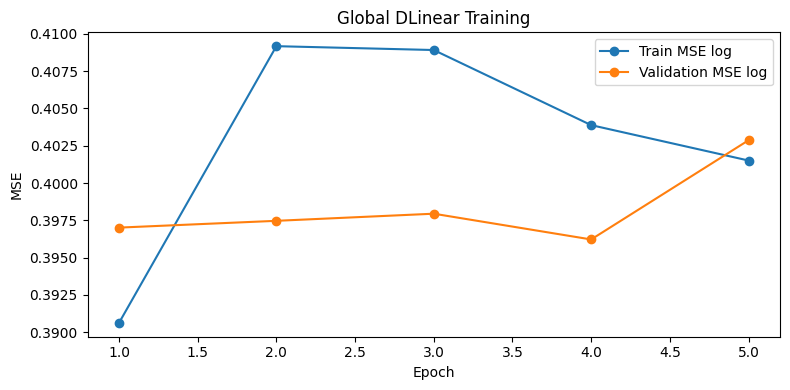

In [58]:
# Plot training and validation loss on the log-sales scale.

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_mse_log"], marker="o", label="Train MSE log")
plt.plot(history_df["epoch"], history_df["val_mse_log"], marker="o", label="Validation MSE log")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Global DLinear Training")
plt.legend()
plt.tight_layout()
plt.show()

### Results

In [ ]:
# Compare the global DLinear model against simple baselines.

def calculate_metrics(prediction, actual):
    mae = np.mean(np.abs(prediction - actual))
    rmse = np.sqrt(np.mean((prediction - actual) ** 2))
    wape = np.sum(np.abs(prediction - actual)) / (np.sum(np.abs(actual)) + 1e-8)

    return {
        "mae": mae,
        "rmse": rmse,
        "wape": wape,
    }


x_val, y_val_log, actual_sales = build_validation_tensors(
    series_arrays_log,
    series_arrays_sales,
    SEQ_LEN,
    PRED_LEN,
)

model.eval()

with torch.no_grad():
    x_val_tensor = torch.from_numpy(x_val[..., None].copy()).to(device)
    pred_log = model(x_val_tensor).cpu().numpy().squeeze(-1)

pred_sales = np.expm1(pred_log)
pred_sales = np.clip(pred_sales, 0, None)

# Repeat last observation all PRED_LEN
last_value_forecast = np.repeat(x_val[:, -1:], PRED_LEN, axis=1)
last_value_forecast = np.expm1(last_value_forecast)

# Take previous PRED_LEN observations and use them as the prediction
seasonal_naive_forecast = []
for sales_series in series_arrays_sales:
    validation_start = len(sales_series) - PRED_LEN
    previous_28_days = sales_series[validation_start - PRED_LEN : validation_start]
    seasonal_naive_forecast.append(previous_28_days)

seasonal_naive_forecast = np.stack(seasonal_naive_forecast)

# Predicts everuthing as 0
zero_forecast = np.zeros_like(actual_sales)

baseline_results = {
    "zero": calculate_metrics(zero_forecast, actual_sales),
    "last_value": calculate_metrics(last_value_forecast, actual_sales),
    "seasonal_naive_28": calculate_metrics(seasonal_naive_forecast, actual_sales),
    "global_dlinear": calculate_metrics(pred_sales, actual_sales),
}

baseline_df = pd.DataFrame(baseline_results).T
baseline_df

,mae,rmse,wape
zero,2.986988,6.206973,1.000000
last_value,2.569666,4.997246,0.860287
seasonal_naive_28,2.351133,4.454990,0.787125
global_dlinear,1.903764,3.915641,0.637352


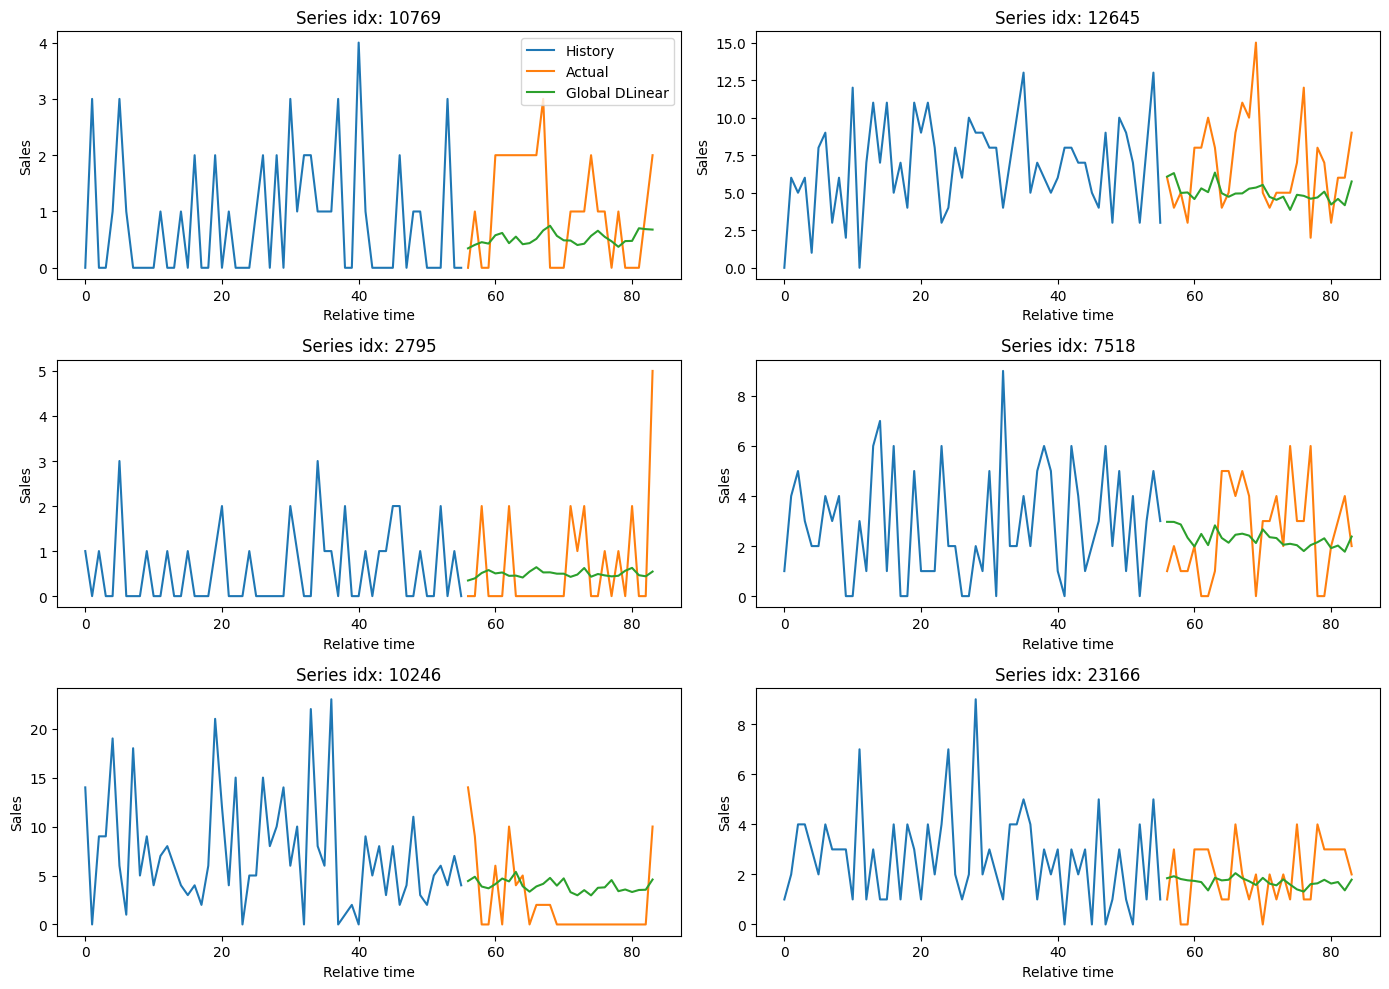

In [61]:
# Plot example forecasts.

plot_positions = np.random.choice(len(series_arrays_sales), size=6, replace=False)

plt.figure(figsize=(14, 10))

for plot_number, position in enumerate(plot_positions, start=1):
    sales_series = series_arrays_sales[position]
    validation_start = len(sales_series) - PRED_LEN

    history_sales = sales_series[validation_start - SEQ_LEN : validation_start]
    true_future = actual_sales[position]
    predicted_future = pred_sales[position]

    history_x = np.arange(SEQ_LEN)
    future_x = np.arange(SEQ_LEN, SEQ_LEN + PRED_LEN)

    plt.subplot(3, 2, plot_number)
    plt.plot(history_x, history_sales, label="History")
    plt.plot(future_x, true_future, label="Actual")
    plt.plot(future_x, predicted_future, label="Global DLinear")

    plt.title(f"Series idx: {series_ids[position]}")
    plt.xlabel("Relative time")
    plt.ylabel("Sales")

    if plot_number == 1:
        plt.legend()

plt.tight_layout()
plt.show()

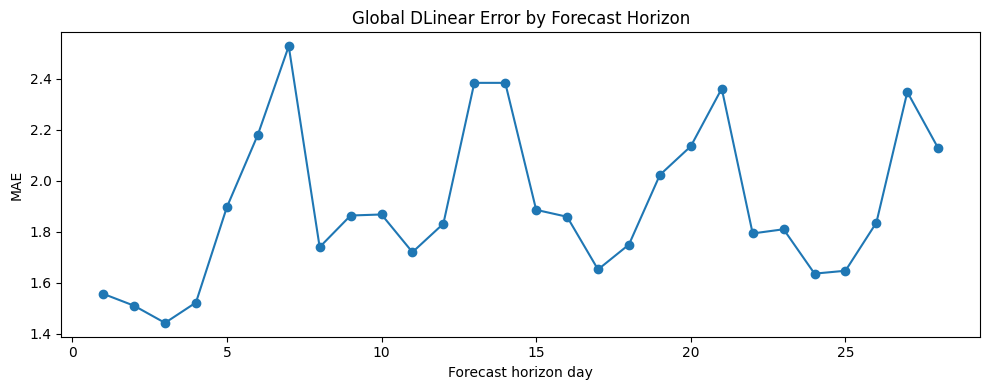

In [60]:
# Plot forecast error by horizon day.

horizon_errors = np.mean(np.abs(pred_sales - actual_sales), axis=0)

plt.figure(figsize=(10, 4))
plt.plot(range(1, PRED_LEN + 1), horizon_errors, marker="o")
plt.xlabel("Forecast horizon day")
plt.ylabel("MAE")
plt.title("Global DLinear Error by Forecast Horizon")
plt.tight_layout()
plt.show()

In [ ]:
# # Save the first global DLinear experiment.

# model_path = PROJECT_ROOT / "notebooks/models/global_dlinear_exploration.pt"

# torch.save(
#     {
#         "model_state_dict": model.state_dict(),
#         "config": {
#             "seq_len": SEQ_LEN,
#             "pred_len": PRED_LEN,
#             "enc_in": 1,
#             "individual": False,
#             "n_series": len(series_arrays_log),
#         },
#         "history": history,
#         "baseline_results": baseline_results,
#     },
#     model_path,
# )

# model_path

WindowsPath('c:/Users/Francisco/Documents/Documentos-secundario/Visual-Studio-Code-Repository/CT5108_Capstone/Unified_forecasting/notebooks/models/global_dlinear_exploration.pt')

: 

: 